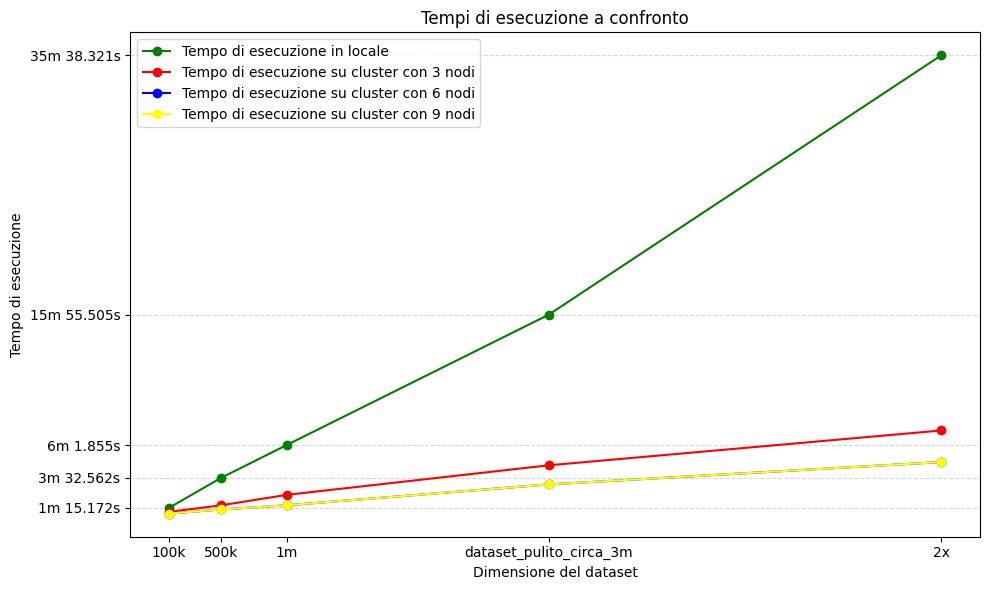

In [1]:
import matplotlib.pyplot as plt

# Dati per l'asse x (comune a tutte le funzioni)
numero_di_righe_dataset = [100_000, 500_000, 1_000_000, 3_000_000, 6_000_000]
x_labels = ['100k', '500k', '1m', 'dataset_pulito_circa_3m', '2x']

# Prima funzione (verde) - da riempire
tempo_verde = [75.172, 212.562, 361.855, 955.505, 2138.321]

# Seconda funzione (rossa) - da riempire
tempo_rosso = [57.286, 87.224, 134.805, 269.440, 428.277]

# Terza funzione (blu) - da riempire
tempo_blu = [49.154, 68.354, 87.295, 182.385, 284.399]

# Terza funzione (blu) - da riempire
tempo_giallo = [31.376, 29.879, 30.817, 30.735, 35.171]

# Funzione per formattare tempo in minuti e secondi con 3 decimali
def format_time(seconds):
    minutes = int(seconds) // 60
    secs = seconds % 60
    if minutes > 0:
        return f"{minutes}m {secs:.3f}s"
    else:
        return f"{secs:.3f}s"

# Etichette asse y (si cosidera solo la prima funzione)
y_labels = [format_time(t) for t in tempo_verde]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Traccia le tre funzioni
ax.plot(numero_di_righe_dataset, tempo_verde, marker='o', linestyle='-', color='green', label='Tempo di esecuzione in locale')
ax.plot(numero_di_righe_dataset, tempo_rosso, marker='o', linestyle='-', color='red', label='Tempo di esecuzione su cluster con 3 nodi')
ax.plot(numero_di_righe_dataset, tempo_blu, marker='o', linestyle='-', color='blue', label='Tempo di esecuzione su cluster con 6 nodi')
ax.plot(numero_di_righe_dataset, tempo_blu, marker='o', linestyle='-', color='yellow', label='Tempo di esecuzione su cluster con 9 nodi')

# Imposta ticks personalizzati
ax.set_xticks(numero_di_righe_dataset)
ax.set_xticklabels(x_labels)

# Etichette y basate sulla funzione verde (puoi adattare se necessario)
ax.set_yticks(tempo_verde)
ax.set_yticklabels(y_labels)

# Etichette assi e titolo
ax.set_xlabel('Dimensione del dataset')
ax.set_ylabel('Tempo di esecuzione')
ax.set_title('Tempi di esecuzione a confronto')
ax.legend()

# Griglia e layout
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
fig.tight_layout()
plt.show()


In [2]:
def format_min_sec(seconds):
    minuti = int(seconds) // 60
    secondi = seconds % 60
    return f"{minuti}m{secondi:.3f}s"

dati = []
for i in range(len(x_labels)):
    dati.append({
        'Dimensione': x_labels[i],
        'Locale': format_min_sec(tempo_verde[i]),
        'Cluster 3 nodi': format_min_sec(tempo_rosso[i]),
        'Cluster 6 nodi': format_min_sec(tempo_blu[i]),
        'Cluster 9 nodi': format_min_sec(tempo_giallo[i]) # se vuoi usarlo
    })

intestazioni = list(dati[0].keys())
larghezze = []
for col in intestazioni:
    max_len = max(len(str(row[col])) for row in dati)
    larghezze.append(max(len(col), max_len))

# Stampa intestazione
header = " | ".join(f"{intestazioni[i]:<{larghezze[i]}}" for i in range(len(intestazioni)))
print(header)
print("-" * len(header))

# Stampa righe
for row in dati:
    riga = " | ".join(f"{str(row[col]):<{larghezze[i]}}" for i, col in enumerate(intestazioni))
    print(riga)


Dimensione              | Locale     | Cluster 3 nodi | Cluster 6 nodi | Cluster 9 nodi
---------------------------------------------------------------------------------------
100k                    | 1m15.172s  | 0m57.286s      | 0m49.154s      | 0m31.376s     
500k                    | 3m32.562s  | 1m27.224s      | 1m8.354s       | 0m29.879s     
1m                      | 6m1.855s   | 2m14.805s      | 1m27.295s      | 0m30.817s     
dataset_pulito_circa_3m | 15m55.505s | 4m29.440s      | 3m2.385s       | 0m30.735s     
2x                      | 35m38.321s | 7m8.277s       | 4m44.399s      | 0m35.171s     
